In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

# ==============================================================================
# 1. DATA LOADER & TRANSLATOR
# ==============================================================================
def load_and_map_tick_data(data_dir: str, symbol: str) -> pd.DataFrame:
    """
    Loads clean partitioned Alpaca tick data into a compact trade-level frame.
    """
    data_path = Path(data_dir) / symbol
    files = sorted(data_path.glob(f"{symbol}_clean_*.csv"))

    if not files:
        raise FileNotFoundError(f"No files found for {symbol} in {data_dir}.")

    print(f"Found {len(files)} daily files. Loading...")

    df_list = []
    failed_files = []
    for file in files:
        file_path = str(file)
        try:
            df_list.append(
                pd.read_csv(
                    file_path,
                    usecols=["timestamp", "price", "size"],
                    dtype={"price": "float64", "size": "float64"},
                    engine="python",
                )
            )
        except OSError as exc:
            failed_files.append((file_path, str(exc)))

    if not df_list:
        failure_details = "\n".join(f"{path}: {error}" for path, error in failed_files)
        raise OSError(f"Unable to read any CSV files for {symbol}.\n{failure_details}")

    if failed_files:
        print(f"Skipped {len(failed_files)} unreadable file(s):")
        for path, error in failed_files[:5]:
            print(f" - {path}: {error}")

    df = pd.concat(df_list, ignore_index=True)
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")
    df.sort_values("timestamp", inplace=True)
    df.reset_index(drop=True, inplace=True)

    # Keep only the minimal trade schema needed downstream.
    compact_df = df[["timestamp", "price", "size"]].copy()
    compact_df.rename(columns={"size": "volume"}, inplace=True)
    compact_df["trade_count"] = 1.0

    return compact_df

In [9]:
script_dir = Path(__file__).parent if "__file__" in globals() else Path.cwd()
market_data_dir = "G:/Mi unidad/2026/Tesis/Códigos/Tools/market_data"#script_dir / "market_data"
output_dir = script_dir / "bars_output"
output_dir.mkdir(exist_ok=True)

symbol = "SPY"

print(f"Loading tick data for {symbol}...")
df = load_and_map_tick_data(str(market_data_dir), symbol)
print(f"Loaded {len(df):,} trades.")

Loading tick data for SPY...
Found 198 daily files. Loading...


KeyboardInterrupt: 

In [ ]:

# ==============================================================================
# 2. INTEGRATED BAR FORMATION
# ==============================================================================
def form_bars(
    df: pd.DataFrame,
    bar_type: str,
    target_bars_per_day: int = 390,
    burn_in_days: int = 5,
    ewma_window: int = 21
) -> pd.DataFrame:
    """
    Forms standard or imbalance bars from a compact trade-level frame.
    The input only needs: timestamp, price, volume, and trade_count.
    """
    _EMPTY = pd.DataFrame(columns=['Open', 'High', 'Low', 'Close', 'Volume', 'VWAP'])
    if df.empty:
        return _EMPTY

    bt = bar_type.strip().lower()
    is_imbalance = 'imbalance' in bt

    if bt not in {'tick', 'volume', 'dollar', 'imbalance'}:
        raise ValueError("bar_type must be one of: 'tick', 'volume', 'dollar', 'imbalance'")

    if 'timestamp' not in df.columns or 'price' not in df.columns:
        raise KeyError("Input DataFrame must contain 'timestamp' and 'price' columns.")

    # ------------------------------------------------------------------
    # 1. Build a burn-in mask without materializing large DataFrame copies
    # ------------------------------------------------------------------
    timestamps_all = df['timestamp'].to_numpy(copy=False)
    dates = timestamps_all.astype('datetime64[D]')
    unique_dates = pd.unique(dates)

    if len(unique_dates) <= burn_in_days:
        raise ValueError(f"Insufficient data. Found {len(unique_dates)} days, but require > {burn_in_days} for the burn-in period.")

    burn_in_dates = unique_dates[:burn_in_days]
    burn_in_mask = np.isin(dates, burn_in_dates)
    total_burn_in_days = len(burn_in_dates)

    # Raw columns as NumPy views to avoid DataFrame duplication
    prices_all = df['price'].to_numpy(dtype=np.float64, copy=False)
    volumes_all = df['volume'].to_numpy(dtype=np.float64, copy=False)
    trade_counts_all = df['trade_count'].to_numpy(dtype=np.float64, copy=False)

    if bt == 'tick':
        magnitude_all = trade_counts_all
    elif bt == 'volume':
        magnitude_all = volumes_all
    else:
        magnitude_all = volumes_all * prices_all

    # ------------------------------------------------------------------
    # 2. Compute Initial Expectations from Burn-in Data (streaming)
    # ------------------------------------------------------------------
    total_metric = 0.0
    burn_ticks = 0
    burn_upticks = 0.0
    prev_burn_price = None
    prev_burn_sign = 1.0
    has_main_rows = False

    n_total = len(df)
    for i in range(n_total):
        if burn_in_mask[i]:
            burn_ticks += 1
            total_metric += magnitude_all[i]

            if is_imbalance:
                price = prices_all[i]
                if prev_burn_price is None:
                    sign = 1.0
                else:
                    diff = price - prev_burn_price
                    sign = np.sign(diff)
                    if sign == 0:
                        sign = prev_burn_sign
                prev_burn_price = price
                prev_burn_sign = sign
                if sign == 1.0:
                    burn_upticks += 1.0
        else:
            has_main_rows = True

    if not has_main_rows:
        return _EMPTY

    initial_expected_magnitude = total_metric / (total_burn_in_days * target_bars_per_day)
    initial_p_uptick = (burn_upticks / burn_ticks) if (is_imbalance and burn_ticks > 0) else 0.5

    print(f"[{bt.upper()} BARS] Burn-in complete. Initial expected magnitude per bar: {initial_expected_magnitude:,.2f}")

    # ------------------------------------------------------------------
    # 3. Bar formation loop (Autonomous Event-Driven State Machine)
    # ------------------------------------------------------------------
    out_open = []
    out_high = []
    out_low = []
    out_close = []
    out_vol = []
    out_vwap = []
    out_times = []

    cumulative_sum = 0.0
    current_high = -np.inf
    current_low = np.inf
    current_open = None
    current_vol = 0.0
    current_dollar = 0.0

    bar_actual_magnitude = 0.0
    bar_upticks = 0.0
    bar_ticks = 0.0

    alpha = 2.0 / (ewma_window + 1.0)
    expected_magnitude = initial_expected_magnitude
    expected_p_uptick = initial_p_uptick

    if is_imbalance:
        bar_threshold = expected_magnitude * max(abs(2.0 * expected_p_uptick - 1.0), 0.01)
    else:
        bar_threshold = expected_magnitude

    prev_main_price = None
    prev_main_sign = 1.0

    for i in range(n_total):
        if burn_in_mask[i]:
            continue

        price = prices_all[i]
        v = volumes_all[i]
        magnitude = magnitude_all[i]

        if current_open is None:
            current_open = price

        if price > current_high:
            current_high = price
        if price < current_low:
            current_low = price

        if is_imbalance:
            if prev_main_price is None:
                sign = 1.0
            else:
                diff = price - prev_main_price
                sign = np.sign(diff)
                if sign == 0:
                    sign = prev_main_sign
            prev_main_price = price
            prev_main_sign = sign
            value = sign * magnitude
            if sign == 1.0:
                bar_upticks += 1.0
        else:
            value = magnitude

        cumulative_sum += value
        bar_actual_magnitude += magnitude
        bar_ticks += 1.0

        current_vol += v
        current_dollar += price * v

        if is_imbalance:
            trigger = abs(cumulative_sum) >= bar_threshold
        else:
            trigger = cumulative_sum >= bar_threshold

        if trigger:
            out_open.append(current_open)
            out_high.append(current_high)
            out_low.append(current_low)
            out_close.append(price)
            out_vol.append(current_vol)
            out_vwap.append(current_dollar / current_vol if current_vol > 0 else price)
            out_times.append(timestamps_all[i])

            # Update Event-Driven Expectations
            expected_magnitude = (alpha * bar_actual_magnitude) + ((1.0 - alpha) * expected_magnitude)

            if is_imbalance:
                p_uptick = bar_upticks / bar_ticks if bar_ticks > 0 else 0.5
                expected_p_uptick = (alpha * p_uptick) + ((1.0 - alpha) * expected_p_uptick)
                bar_threshold = expected_magnitude * max(abs(2.0 * expected_p_uptick - 1.0), 0.01)
            else:
                bar_threshold = expected_magnitude

            # Reset accumulator state
            cumulative_sum = 0.0
            bar_actual_magnitude = 0.0
            bar_upticks = 0.0
            bar_ticks = 0.0
            current_high = -np.inf
            current_low = np.inf
            current_open = None
            current_vol = 0.0
            current_dollar = 0.0

    # ------------------------------------------------------------------
    # 4. Assemble output
    # ------------------------------------------------------------------
    bars_df = pd.DataFrame({
        'Open': out_open,
        'High': out_high,
        'Low': out_low,
        'Close': out_close,
        'Volume': out_vol,
        'VWAP': out_vwap,
    }, index=out_times)

    bars_df.index.name = 'timestamp'
    return bars_df

# ==============================================================================
# 3. EXECUTION
# ==============================================================================
if __name__ == "__main__":


    # Form Bars
    print("\nForming Tick Bars...")
    tick_bars = form_bars(df, bar_type='tick', target_bars_per_day=390, burn_in_days=21)
    tick_bars.to_csv(output_dir / f"{symbol}_tick_bars.csv")
    print(f" -> Generated {len(tick_bars):,} tick bars.")

    print("\nForming Volume Bars...")
    volume_bars = form_bars(df, bar_type='volume', target_bars_per_day=390, burn_in_days=21)
    volume_bars.to_csv(output_dir / f"{symbol}_volume_bars.csv")
    print(f" -> Generated {len(volume_bars):,} volume bars.")

    print("\nForming Dollar Bars...")
    dollar_bars = form_bars(df, bar_type='dollar', target_bars_per_day=390, burn_in_days=21)
    dollar_bars.to_csv(output_dir / f"{symbol}_dollar_bars.csv")
    print(f" -> Generated {len(dollar_bars):,} dollar bars.")

    print(f"\nAll operations complete. Bars saved to: {output_dir}")


Forming Tick Bars...
[TICK BARS] Burn-in complete. Initial expected magnitude per bar: 1,170.16
 -> Generated 10,761 tick bars.

Forming Volume Bars...
[VOLUME BARS] Burn-in complete. Initial expected magnitude per bar: 93,360.94
 -> Generated 2,383 volume bars.

Forming Dollar Bars...
[DOLLAR BARS] Burn-in complete. Initial expected magnitude per bar: 55,534,294.48
 -> Generated 2,375 dollar bars.

All operations complete. Bars saved to: g:\Mi unidad\2026\Tesis\Códigos\AnalisisGeneral\bars_output


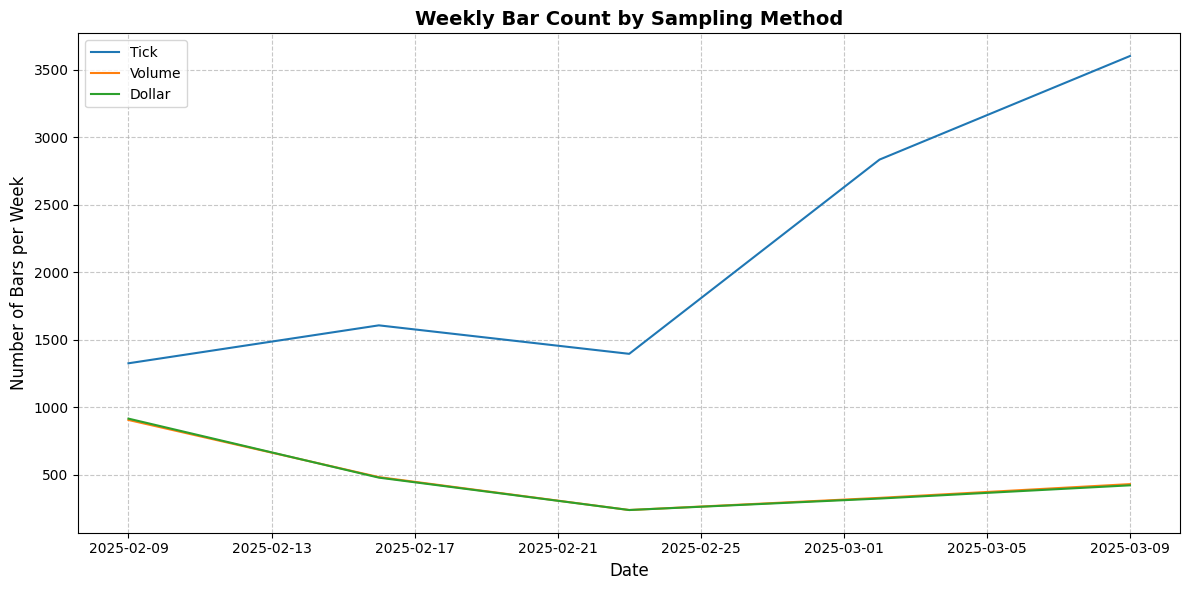

Stability Analysis (Coefficient of Variation):
          Mean          Std        CV
Tick    2152.2  1014.866839  0.471549
Volume   476.6   257.264067  0.539790
Dollar   475.0   262.582368  0.552805


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def analyze_bar_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Calculates weekly bar counts, plots the time series, and computes the
    Coefficient of Variation (CV) for stability analysis.

    Parameters:
    bars_dict: dict mapping bar_type (str) to its corresponding DataFrame of bars.
               DataFrames must have a DatetimeIndex.
    """
    weekly_counts = {}

    fig, ax = plt.subplots(figsize=(12, 6))

    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")

        # Resample to weekly frequency and count the number of bars
        counts = df.resample('W').size()
        weekly_counts[bar_type] = counts

        # Plotting
        ax.plot(counts.index, counts.values, label=bar_type, linewidth=1.5)

    ax.set_title("Weekly Bar Count by Sampling Method", fontsize=14, fontweight='bold')
    ax.set_ylabel("Number of Bars per Week", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.tight_layout()
    plt.show()

    # Calculate and display the Coefficient of Variation
    cv_results = {}
    for bar_type, counts in weekly_counts.items():
        mean_count = counts.mean()
        std_count = counts.std()
        cv = std_count / mean_count if mean_count > 0 else np.nan
        cv_results[bar_type] = {'Mean': mean_count, 'Std': std_count, 'CV': cv}

    cv_df = pd.DataFrame(cv_results).T
    print("Stability Analysis (Coefficient of Variation):")
    print(cv_df.sort_values('CV'))

    return cv_df


# Example usage (assuming tick_df, vol_df, dollar_df exist):
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars}
stats_df = analyze_bar_stability(bars_dict)

In [ ]:
import pandas as pd
import numpy as np

def compute_serial_correlation(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the first-order serial correlation of log returns for given bar types.
    
    Parameters:
    bars_dict: dict mapping bar_type (str) to a DataFrame containing a 'Close' column.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # Compute log returns. 
        # Using log returns is non-negotiable for additive multi-period properties.
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        
        # Calculate lag-1 autocorrelation
        rho_1 = returns.autocorr(lag=1)
        
        # Calculate absolute autocorrelation (critical for microstructure evaluation)
        abs_rho_1 = np.abs(rho_1)
        
        results[bar_type] = {
            'rho_1': rho_1, 
            '|rho_1|': abs_rho_1,
            'Sample_Size': len(returns)
        }
        
    results_df = pd.DataFrame(results).T
    # Sort by the lowest absolute serial correlation
    return results_df.sort_values('|rho_1|')

# Example Usage:
bars_dict = {'Tick': tick_bars, 'Volume': volume_bars, 'Dollar': dollar_bars}#, 'Imbalance': imbalance_bars}
autocorr_stats = compute_serial_correlation(bars_dict)
print(autocorr_stats)



           rho_1   |rho_1|  Sample_Size
Dollar -0.024941  0.024941       2374.0
Tick   -0.025759  0.025759      10760.0
Volume -0.061828  0.061828       2382.0


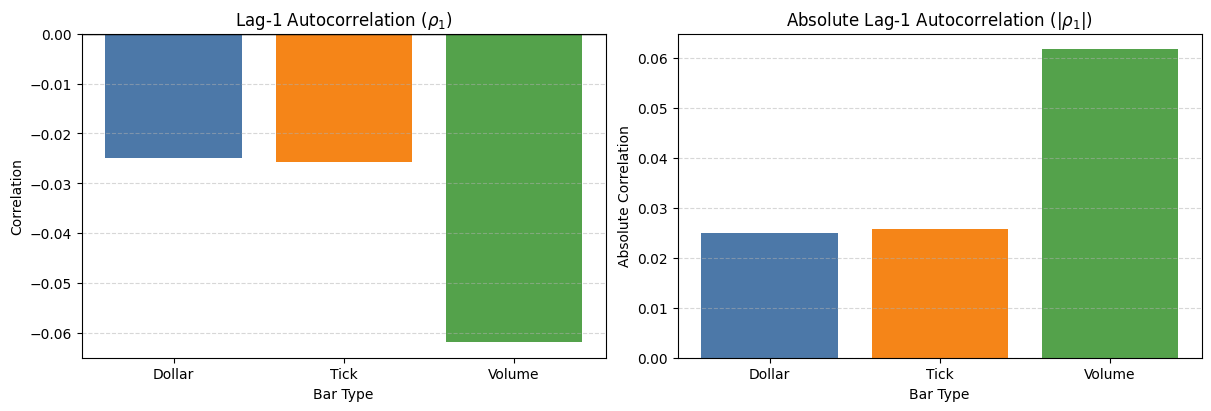

In [ ]:
import matplotlib.pyplot as plt

# Plot serial correlation metrics by bar type
plot_df = autocorr_stats.copy()
plot_df.index = plot_df.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Signed lag-1 autocorrelation
axes[0].bar(plot_df.index, plot_df['rho_1'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Lag-1 Autocorrelation ($\\rho_1$)')
axes[0].set_ylabel('Correlation')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Absolute lag-1 autocorrelation (lower is better for microstructure noise)
axes[1].bar(plot_df.index, plot_df['|rho_1|'], color=['#4C78A8', '#F58518', '#54A24B'])
axes[1].set_title('Absolute Lag-1 Autocorrelation ($|\\rho_1|$)')
axes[1].set_ylabel('Absolute Correlation')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for ax in axes:
    ax.set_xlabel('Bar Type')

plt.show()

In [ ]:
import pandas as pd
import numpy as np


def analyze_variance_stability(bars_dict: dict) -> pd.DataFrame:
    """
    Partitions bar series into monthly subsets, computes the variance of returns
    for each month, and evaluates the stability of those variances.
    """
    results = {}

    for bar_type, df in bars_dict.items():
        if not isinstance(df.index, pd.DatetimeIndex):
            raise TypeError(f"Index of {bar_type} DataFrame must be a DatetimeIndex.")

        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()

        # 2. Partition into monthly subsets and compute variance
        monthly_variances = returns.groupby(pd.Grouper(freq='M')).var().dropna()

        # 3. Compute statistics on the variances
        var_of_vars = monthly_variances.var()
        mean_var = monthly_variances.mean()

        # Dimensionless stability metric
        cv_of_vars = np.sqrt(var_of_vars) / mean_var if mean_var > 0 else np.nan

        results[bar_type] = {
            'Mean_Monthly_Variance': mean_var,
            'Variance_of_Variances': var_of_vars,
            'CV_of_Variances': cv_of_vars
        }

    results_df = pd.DataFrame(results).T

    # Sort by the dimensionally correct metric, not the raw variance of variances
    return results_df.sort_values('CV_of_Variances')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
stability_stats = analyze_variance_stability(bars_dict)
print(stability_stats)

        Mean_Monthly_Variance  Variance_of_Variances  CV_of_Variances
Tick             1.923614e-07           8.268456e-14         1.494838
Volume           1.440917e-06           6.127288e-12         1.717889
Dollar           1.448737e-06           6.387662e-12         1.744542


C:\Users\migue\AppData\Local\Temp\ipykernel_17240\3730552322.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  monthly_variances = returns.groupby(pd.Grouper(freq='H')).var()


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

def compute_normality_tests(bars_dict: dict) -> pd.DataFrame:
    """
    Computes the Jarque-Bera test statistic for log returns of given bar types.
    WARNING: This comparison is mathematically invalid if lengths of returns (n) differ significantly.
    """
    results = {}
    
    for bar_type, df in bars_dict.items():
        if 'Close' not in df.columns:
            raise KeyError(f"DataFrame for {bar_type} must contain a 'Close' column.")
            
        # 1. Compute log returns
        returns = np.log(df['Close'] / df['Close'].shift(1)).dropna()
        n = len(returns)
        
        # 2. Compute Skewness and Kurtosis (Fisher definition where Normal Kurtosis = 0)
        skewness = stats.skew(returns)
        # scipy.stats.kurtosis computes EXCESS kurtosis by default (K-3)
        excess_kurtosis = stats.kurtosis(returns, fisher=True) 
        
        # 3. Compute Jarque-Bera
        jb_stat, p_value = stats.jarque_bera(returns)
        
        results[bar_type] = {
            'N': n,
            'Skewness': skewness,
            'Excess_Kurtosis': excess_kurtosis,
            'JB_Statistic': jb_stat,
            'p_value': p_value
        }
        
    results_df = pd.DataFrame(results).T
    
    # Sort by lowest JB Statistic
    return results_df.sort_values('JB_Statistic')

# Example Usage:
# bars_dict = {'Tick': tick_df, 'Volume': vol_df, 'Dollar': dollar_df}
jb_stats = compute_normality_tests(bars_dict)
print(jb_stats)

              N  Skewness  Excess_Kurtosis  JB_Statistic  p_value
Volume   2382.0 -1.517175        22.231166  4.996563e+04      0.0
Dollar   2374.0 -1.447150        22.650466  5.157719e+04      0.0
Tick    10760.0 -3.047581        91.842704  3.798385e+06      0.0
